### Python Task:
#### EDA Task:
    Task-1: Perform descriptive statistical analysis for numerical features
    Task-2: Visualize the distribution of categorical features - race and gender
    Task-3: Explore the relationship between readmission status and age
    Task-4: Investigate correlations between numerical features
    Task-5: Analyze the distribution of medication changes and total medications taken
    Task-6: Examine the distribution of diagnoses categories
    Task-7: Explore the distribution of patients across admission types, sources, and discharge dispositions
    Task-8: Identify and visualize any outliers in the dataset, especially in numerical features
    Task-9: Write an analysis report on performing exploratory data analysis (EDA) using Python in the context of building a fraud detection system                for the healthcare management system

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as sp

####  Task-1: Perform descriptive statistical analysis for numerical features

In [2]:
df = pd.read_csv("diabetic_data.csv")

In [3]:
df

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101761,443847548,100162476,AfricanAmerican,Male,[70-80),?,1,3,7,3,...,No,Down,No,No,No,No,No,Ch,Yes,>30
101762,443847782,74694222,AfricanAmerican,Female,[80-90),?,1,4,5,5,...,No,Steady,No,No,No,No,No,No,Yes,NO
101763,443854148,41088789,Caucasian,Male,[70-80),?,1,1,7,1,...,No,Down,No,No,No,No,No,Ch,Yes,NO
101764,443857166,31693671,Caucasian,Female,[80-90),?,2,3,7,10,...,No,Up,No,No,No,No,No,Ch,Yes,NO


In [12]:
numerical_stats = df.select_dtypes([float,int]).describe()
print("Descriptive Statistics for Numerical Features:")
numerical_stats

Descriptive Statistics for Numerical Features:


,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


#### Task-2: Visualize the distribution of categorical features - race and gender

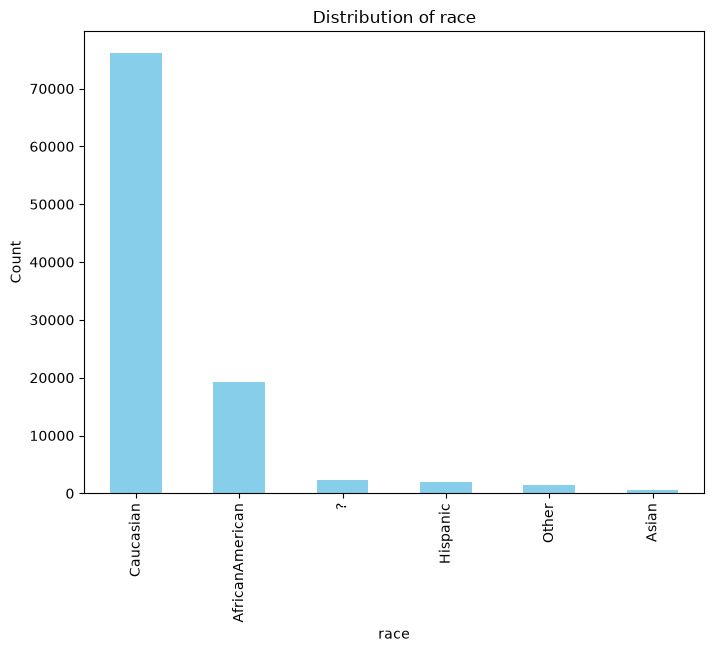

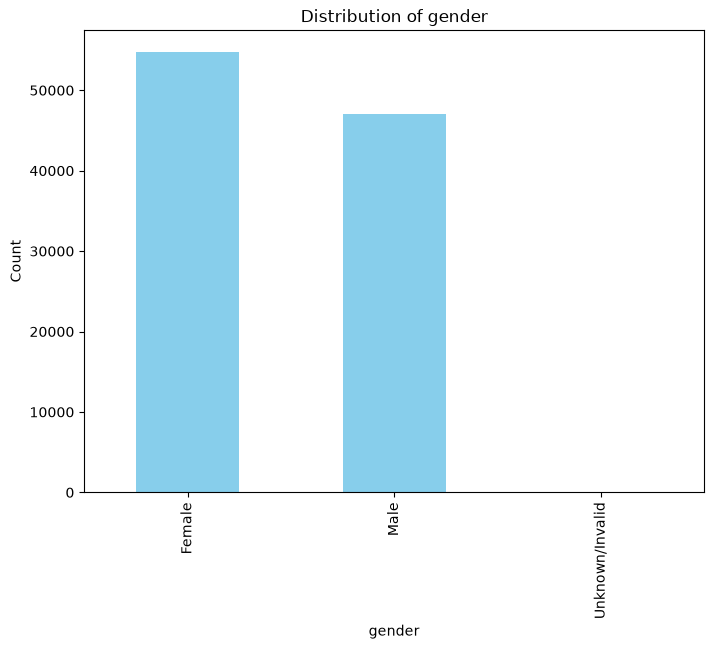

In [17]:
categorical_features = ['race','gender']

for feature in categorical_features:
    plt.figure(figsize =(8,6))
    df[feature].value_counts().plot(kind='bar',color='skyblue')
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

# Heading 1
## Heading 2
### Heading 3
#### Heading 4
##### Heading 5
###### Heading 6

#### Task-3: Explore the relationship between readmission status and age

##### pd.crosstab() is a Pandas function used to count the frequency of combinations of two or more categorical variables.

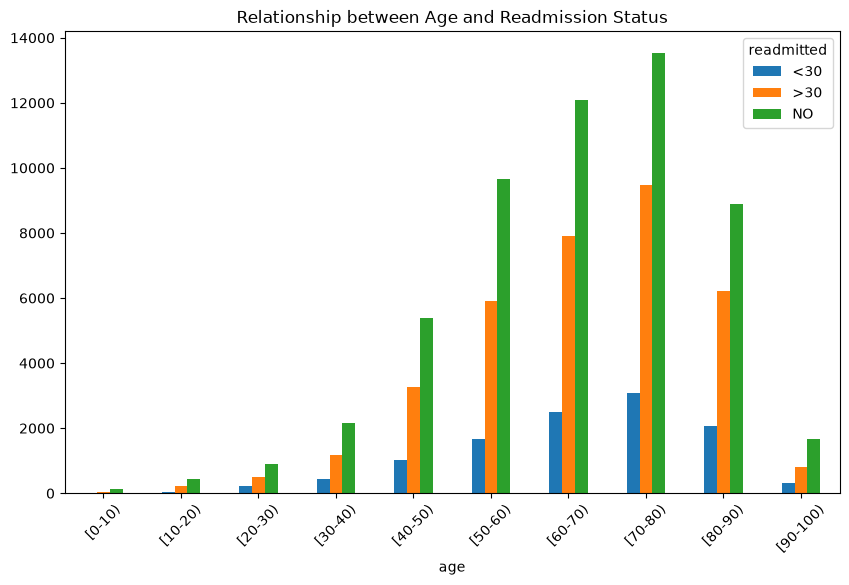

In [25]:
counts = pd.crosstab(df['age'],df['readmitted'])
counts.plot(kind='bar',figsize=(10,6))
plt.title('Relationship between Age and Readmission Status')
plt.xticks(rotation=45)
plt.show()

####  Task-4: Investigate correlations between numerical features

###### annot -> Annotation - It displays the numeric value inside every cell.
###### cmap -> Color Map - It determines the colors used in the heatmap. 
                            * Blue → Negative correlation
                            * White → Near zero
                            * Red → Positive correlation
###### fmt -> specifies how annotation values are formatted. 
                f → Floating-point number
                .2 → Show 2 digits after the decimal point
###### annot_kws ->  annotation keywords. This sets the annotation font size to 10.

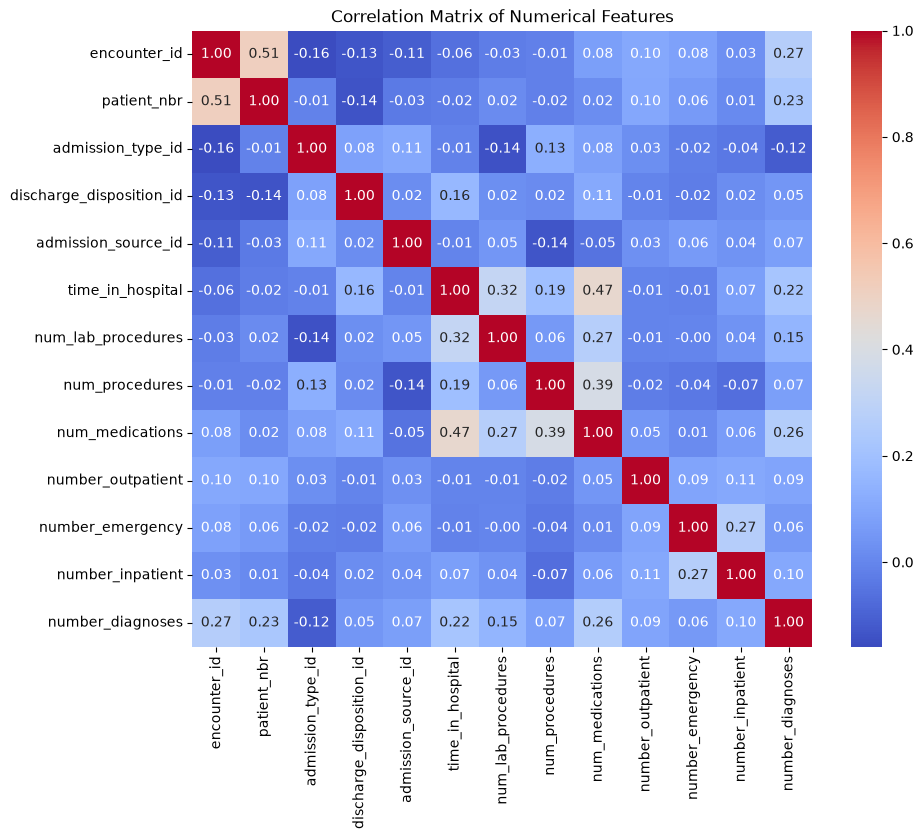

In [32]:
correlation_matrix = df.select_dtypes([float,int]).corr()
plt.figure(figsize=(10,8))
sns.heatmap(data=correlation_matrix,annot=True,cmap='coolwarm',fmt='.2f',annot_kws={"size":10})
plt.title('Correlation Matrix of Numerical Features')
plt.show()

#### Task-5: Analyze the distribution of medication changes and total medications taken

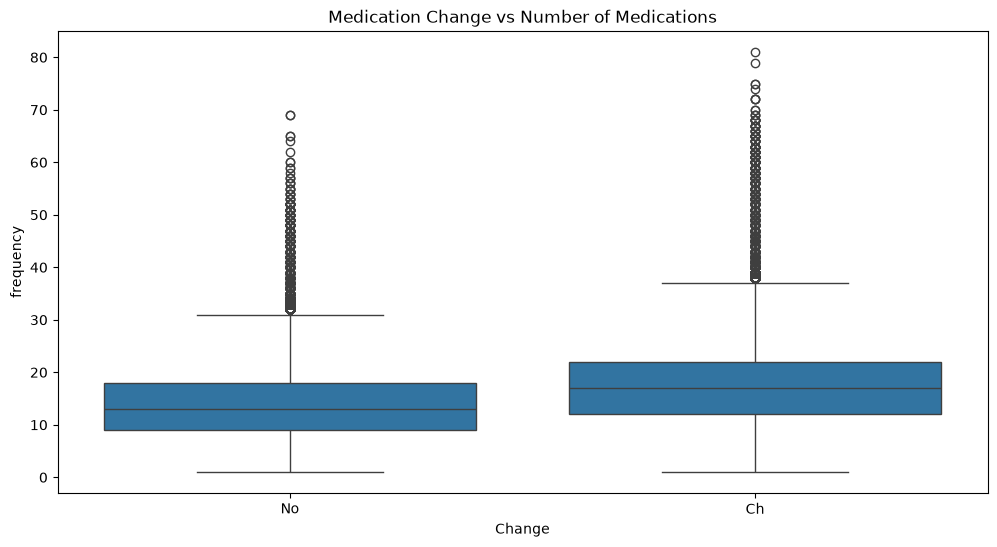

In [22]:
plt.figure(figsize=(12,6))
sns.boxplot(x='change',y='num_medications',data=df)
plt.title('Medication Change vs Number of Medications')
plt.xlabel('Change')
plt.ylabel('frequency')
plt.show()

#### Task-6: Examine the distribution of diagnoses categories

In [12]:
df['diag_1'].value_counts().head(10)

diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
427    2766
491    2275
715    2151
682    2042
434    2028
Name: count, dtype: int64

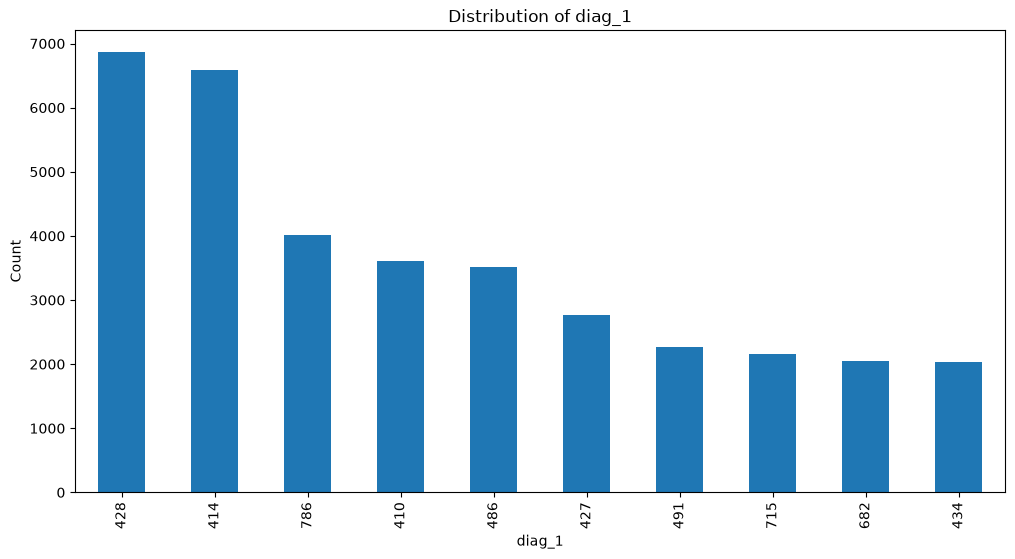

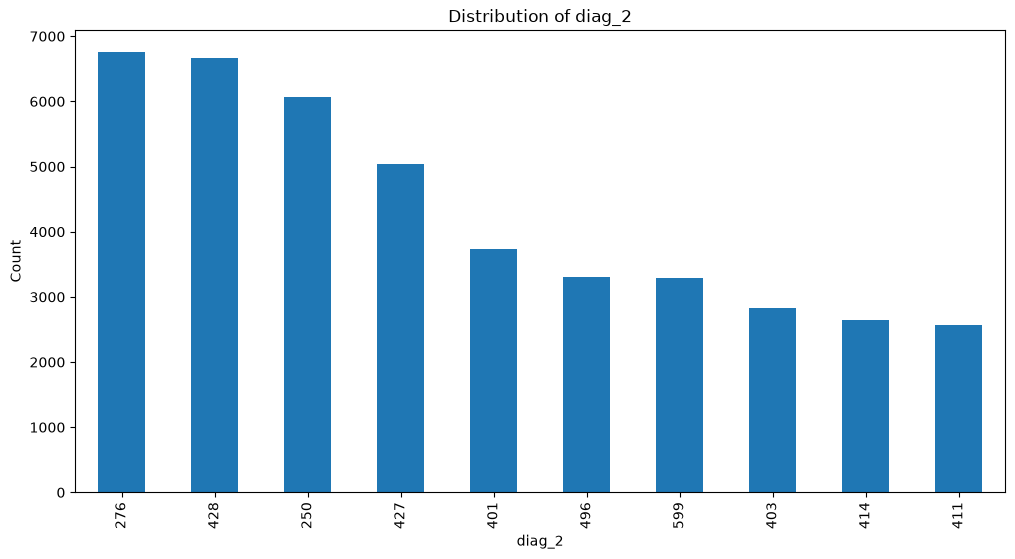

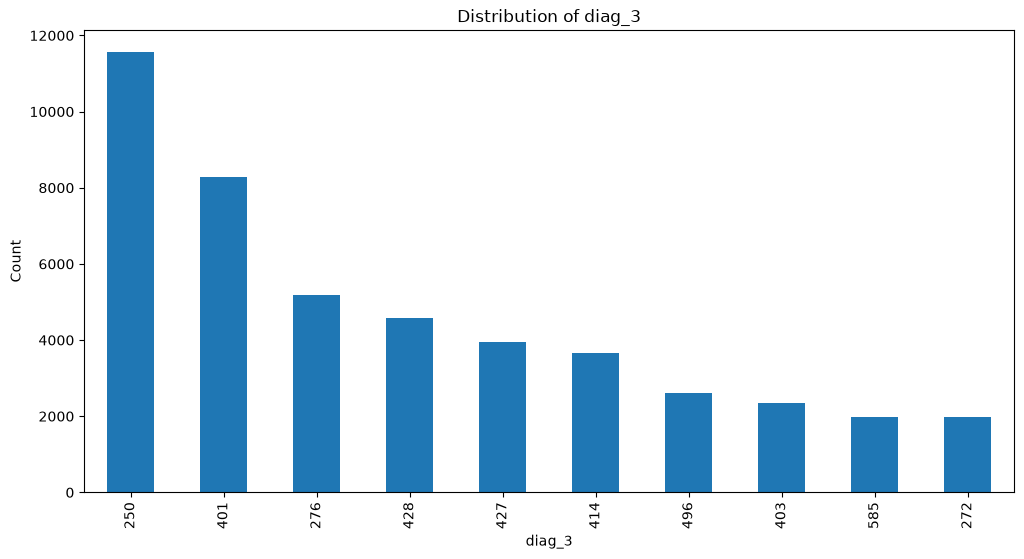

In [13]:
diagnosis_features = ['diag_1','diag_2','diag_3']
for feature in diagnosis_features:
    plt.figure(figsize=(12,6))
    df[feature].value_counts().head(10).plot(kind='bar')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

#### Task-7: Explore the distribution of patients across admission types, sources, and discharge dispositions

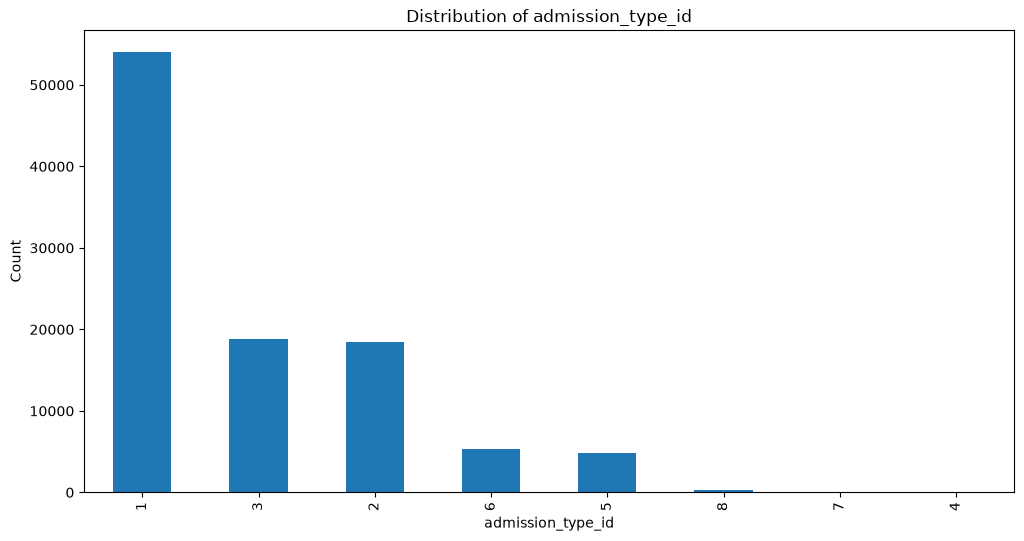

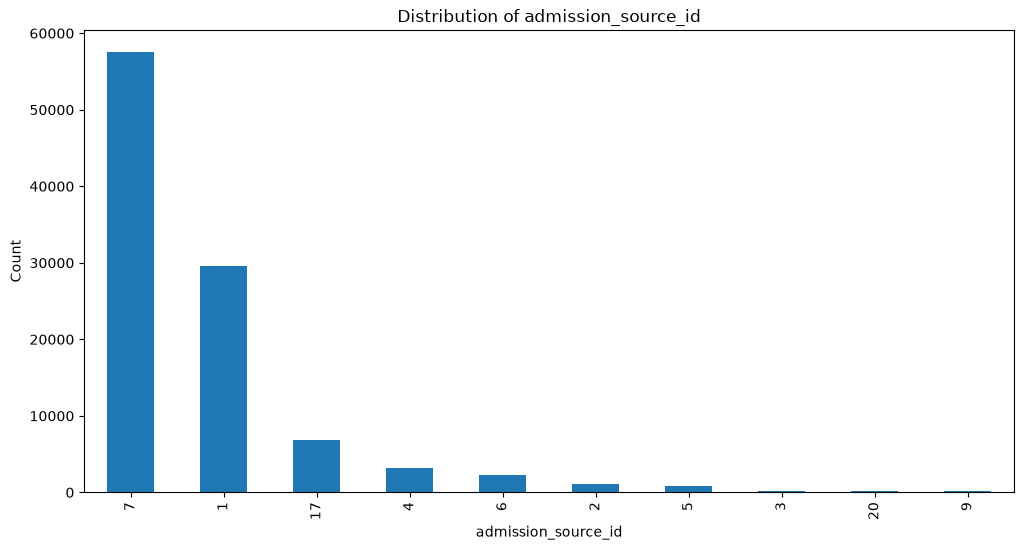

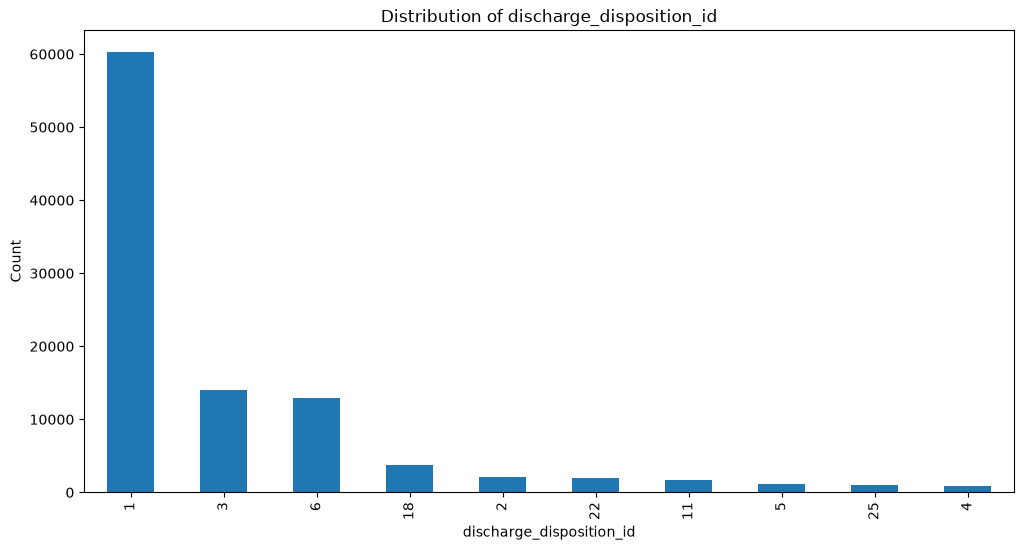

In [14]:
admission_features = ['admission_type_id', 'admission_source_id', 'discharge_disposition_id']

for feature in admission_features:
    plt.figure(figsize=(12,6))
    df[feature].value_counts().head(10).plot(kind='bar')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

####  Task-8: Identify and visualize any outliers in the dataset, especially in numerical features

In [16]:
numerical_col = df.select_dtypes([float,int])

In [17]:
# Remove ID columns (not useful for outlier detection)
numerical_col = [col for col in numerical_col
                    if col not in ['encounter_id','patient_nbr']]

numerical_col

['admission_type_id',
 'discharge_disposition_id',
 'admission_source_id',
 'time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'number_diagnoses']

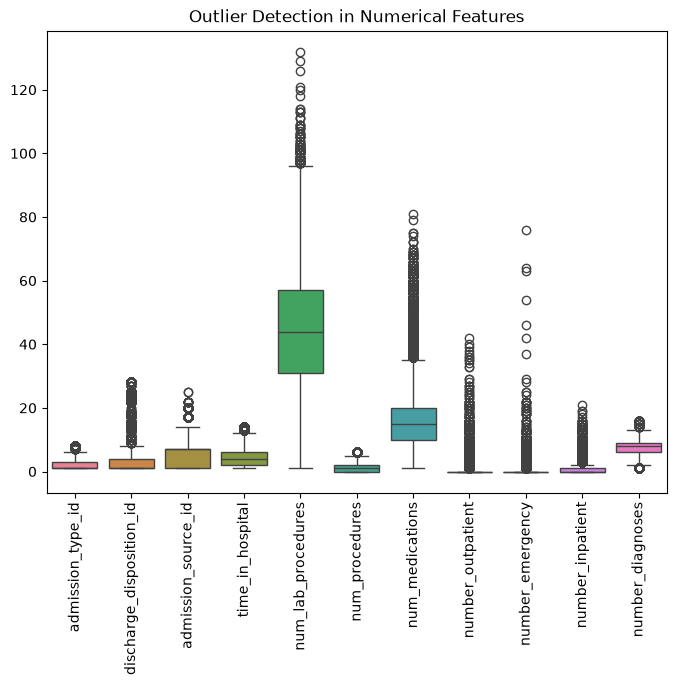

In [20]:
plt.figure(figsize = (8,6))
sns.boxplot(data=df[numerical_col])
plt.title('Outlier Detection in Numerical Features')
plt.xticks(rotation=90)
plt.show()

####     Task-9: Write an analysis report on performing exploratory data analysis (EDA) using Python in the context of building a fraud detection system                for the healthcare management system

##### Observations:

#####   1. Descriptive Statistics for Numerical Features:

- The describe() function provides statistical summaries for numerical features like mean, standard deviation, minimum, maximum, and quartiles.
- For instance, looking at num_medications, the average number of medications taken by patients is approximately 16, with a standard deviation of around 8.13.
- Another example is num_lab_procedures, where the mean number of lab procedures conducted is about 43.10, with a standard deviation of approximately 19.68.

#####  2. Descriptive Statistics for Numerical Features:

+ Visualizations depict the distribution of categorical features such as race and gender.
+ For instance, the bar plot for race illustrates the count of patients belonging to different racial groups.
+ Similarly, the distribution of gender shows the count of male and female patients.

##### 3. Relationship between Age and Readmission Status:

+ The bar plot demonstrates the relationship between patients' ages and their readmission status.
+ It helps in understanding if there's any correlation between age groups and the likelihood of readmission.

##### 4. Correlation Matrix of Numerical Features:

+ The heatmap visualizes the correlation between different numerical features.
+ It helps identify potential relationships between variables, such as positive or negative correlations.

##### 5. Distribution of Medication Changes and Total Medications Taken:

+ The boxplot presents the distribution of medication changes concerning the total number of medications taken.
+ It assists in analyzing the impact of medication changes on the total medication count.

##### 6. Distribution of Diagnoses Categories:

+ Bar plots display the distribution of diagnoses categories, including 'diag_1', 'diag_2', and 'diag_3'.
+ These plots provide insights into the frequency of different diagnosis codes among patients.

##### 7. Distribution of Patients across Admission Types, Sources, and Discharge Dispositions:

+ Bar plots showcase the distribution of patients across various admission types, admission sources, and discharge dispositions.
+ Understanding these distributions is crucial for analyzing the patterns of patient admissions and discharges.

##### 8. Identify and visualize any outliers in the dataset, especially in numerical features

+ More outliers are in Lab Procedures and Medications